# Exercícios — k-NN e Naive Bayes

**Tema:** Aprendizado Supervisionado › k-NN e Naive Bayes

Resolva antes de olhar o gabarito. **Dificuldade:** 🟢 base · 🟡 aplicação ·
🔴 síntese

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error

rng = np.random.default_rng(1212)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
AZUL, VERDE, VERMELHO, ROXO, AMBAR = "#1F5C8B", "#1E6B4F", "#9C2B2B", "#5B3E86", "#8A6100"
print("ambiente pronto")

ambiente pronto


---
## Exercício 1 🟢 — k=1 sempre acerta o treino

Prove, com qualquer dataset de sua escolha, que `KNeighborsClassifier(n_neighbors=1)`
tem acurácia de treino exatamente 1.0. Explique por quê em uma frase.

In [2]:
# --- sua resposta ---

### Gabarito 1

In [3]:
n = 200
X = rng.normal(0, 1, (n, 3))
y = rng.integers(0, 2, n)

modelo_k1 = KNeighborsClassifier(n_neighbors=1).fit(X, y)
print(f"acurácia de treino com k=1: {modelo_k1.score(X, y):.6f}")

acurácia de treino com k=1: 1.000000


**Por quê:** com $k=1$, o vizinho mais próximo de qualquer ponto DE TREINO
é ele mesmo (distância zero até si mesmo, sempre menor que a distância até
qualquer outro ponto) — então a previsão para cada ponto de treino é
sempre a própria classe dele.

---
## Exercício 2 🟢 — k-NN para regressão

Gere `y = sin(x) + ruído` para `x` em um intervalo. Ajuste
`KNeighborsRegressor` com k=1, k=10 e k=50. Plote as três curvas de
previsão sobre os dados e descreva o efeito de k na suavidade da curva.

In [4]:
# --- sua resposta ---

### Gabarito 2

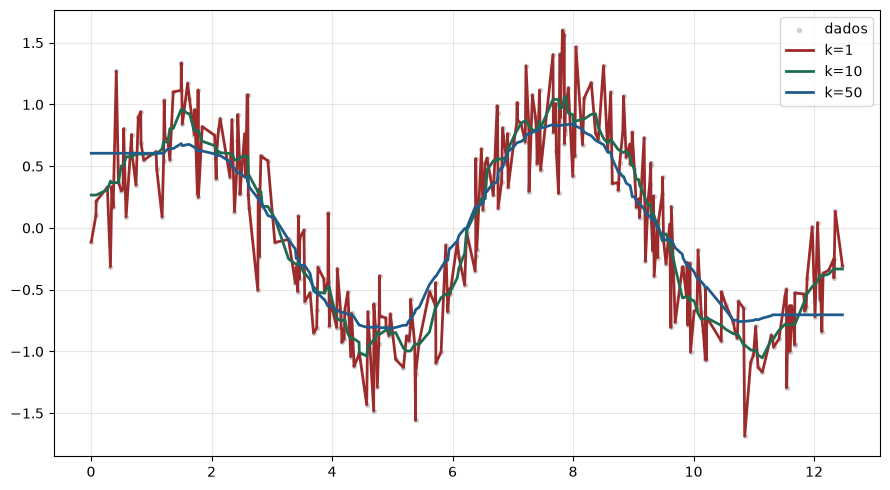

In [5]:
x = np.sort(rng.uniform(0, 4 * np.pi, 300))
y = np.sin(x) + rng.normal(0, 0.3, 300)

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(x, y, s=8, alpha=0.3, color="gray", label="dados")
for k, cor in zip([1, 10, 50], [VERMELHO, VERDE, AZUL]):
    modelo = KNeighborsRegressor(n_neighbors=k).fit(x.reshape(-1, 1), y)
    pred = modelo.predict(x.reshape(-1, 1))
    ax.plot(x, pred, color=cor, lw=2, label=f"k={k}")
ax.legend(); plt.tight_layout(); plt.show()

**Resposta esperada:** k=1 produz uma curva "serrilhada" que passa
exatamente pelos pontos de treino (alta variância); k=50 produz uma curva
muito suave, que pode perder a forma real da senoide nas regiões de maior
curvatura (alto viés); k=10 tende a ficar no meio-termo.

---
## Exercício 3 🟡 — Escolhendo k por validação cruzada, com métrica correta

Para um problema de classificação desbalanceado (~10% positivos), escolha
k por validação cruzada usando `scoring="roc_auc"` em vez de acurácia
(tema 3, módulo 5). Compare o k escolhido pelas duas métricas.

In [6]:
# --- sua resposta ---

### Gabarito 3

In [7]:
n = 1500
X = rng.normal(0, 1, (n, 4))
logit = -2.5 + 1.2 * X[:, 0] - 0.8 * X[:, 1]
y = (rng.random(n) < 1 / (1 + np.exp(-logit))).astype(int)
X_padronizado = StandardScaler().fit_transform(X)

valores_k = [3, 5, 11, 25, 51, 101]
scores_acuracia, scores_auc = [], []
for k in valores_k:
    modelo = KNeighborsClassifier(n_neighbors=k)
    scores_acuracia.append(cross_val_score(modelo, X_padronizado, y, cv=5).mean())
    scores_auc.append(cross_val_score(modelo, X_padronizado, y, cv=5, scoring="roc_auc").mean())

print(f"{'k':>6s} {'acurácia':>10s} {'ROC-AUC':>10s}")
print("-" * 28)
for k, a, auc in zip(valores_k, scores_acuracia, scores_auc):
    print(f"{k:>6d} {a:>10.4f} {auc:>10.4f}")

print(f"\nk escolhido por acurácia: {valores_k[np.argmax(scores_acuracia)]}")
print(f"k escolhido por ROC-AUC : {valores_k[np.argmax(scores_auc)]}")

     k   acurácia    ROC-AUC
----------------------------
     3     0.8567     0.6515
     5     0.8633     0.6781
    11     0.8693     0.7485
    25     0.8760     0.8018
    51     0.8727     0.8095
   101     0.8680     0.8229

k escolhido por acurácia: 25
k escolhido por ROC-AUC : 101


**Resposta esperada:** com 10% de positivos, a acurácia pode ficar quase
plana em vários valores de k (o modelo "trapaceia" prevendo a maioria)
— o mesmo problema do tema 3, módulo 5, agora afetando a ESCOLHA de
hiperparâmetro, não só a avaliação final. Escolher k pela métrica certa
evita otimizar para o número errado.

---
## Exercício 4 🟡 — Laplace smoothing e o efeito do tamanho do vocabulário

Implemente Naive Bayes Multinomial do zero (probabilidade de cada palavra
dado a classe, com suavização de Laplace) para um dataset pequeno de
textos. Compare a previsão com `alpha=1` e `alpha=100` (suavização
excessiva) — o que acontece com a confiança do modelo quando alpha é
grande demais?

In [8]:
# --- sua resposta ---

### Gabarito 4

In [9]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB

documentos = [
    "ótimo atendimento rápido", "excelente produto recomendo",
    "péssimo atendimento demorado", "produto ruim não recomendo",
    "atendimento rápido e ótimo", "recomendo o produto excelente",
]
rotulos = ["positivo", "positivo", "negativo", "negativo", "positivo", "positivo"]

vetorizador = CountVectorizer()
X_vet = vetorizador.fit_transform(documentos)
teste = vetorizador.transform(["atendimento ótimo"])

for alpha in [1.0, 100.0]:
    modelo = MultinomialNB(alpha=alpha).fit(X_vet, rotulos)
    prob = modelo.predict_proba(teste)[0]
    print(f"alpha={alpha:>6.1f}: P(positivo)={prob[1]:.4f}  P(negativo)={prob[0]:.4f}")

alpha=   1.0: P(positivo)=0.8431  P(negativo)=0.1569
alpha= 100.0: P(positivo)=0.6710  P(negativo)=0.3290


**Resposta esperada:** com `alpha=100`, muito maior que as contagens reais
de palavras no dataset (só algumas unidades), a suavização passa a dominar
a estimativa — as probabilidades condicionais de todas as palavras ficam
artificialmente próximas da uniforme, e a previsão final se aproxima de
50/50, mesmo quando a evidência das palavras deveria apontar claramente
para uma classe. Suavização demais é tão problemática quanto suavização de
menos — ela "apaga" o sinal real dos dados.

---
## Exercício 5 🔴 — k-NN vs. Naive Bayes em alta dimensionalidade

Gere um dataset com $n=500$ e compare o desempenho (5-fold CV) de k-NN
(com k escolhido por CV interna) e Naive Bayes Gaussiano conforme o número
de features cresce: 5, 50, 500, 2000 (mantendo só 5 features realmente
informativas, o resto ruído). Explique o padrão observado usando os
conceitos deste módulo.

In [10]:
# --- sua resposta ---

### Gabarito 5

In [11]:
def experimento_dimensionalidade(n_features_total, n=500, n_informativas=5):
    X_informativo = rng.normal(0, 1, (n, n_informativas))
    beta = rng.normal(0, 1.5, n_informativas)
    logit = X_informativo @ beta
    y = (rng.random(n) < 1 / (1 + np.exp(-logit))).astype(int)

    X_ruido = rng.normal(0, 1, (n, n_features_total - n_informativas))
    X_completo = StandardScaler().fit_transform(np.column_stack([X_informativo, X_ruido]))

    acc_knn = cross_val_score(KNeighborsClassifier(n_neighbors=15), X_completo, y, cv=5).mean()
    acc_nb = cross_val_score(GaussianNB(), X_completo, y, cv=5).mean()
    return acc_knn, acc_nb


print(f"{'nº features':>12s} {'k-NN (k=15)':>14s} {'Naive Bayes':>14s}")
print("-" * 42)
for n_features in [5, 50, 500, 2000]:
    acc_knn, acc_nb = experimento_dimensionalidade(n_features)
    print(f"{n_features:>12d} {acc_knn:>14.4f} {acc_nb:>14.4f}")

 nº features    k-NN (k=15)    Naive Bayes
------------------------------------------
           5         0.8260         0.8520
          50         0.6900         0.8020


         500         0.5100         0.5900


        2000         0.5260         0.6500


**Resposta esperada:** a acurácia do k-NN tende a **degradar** conforme o
número de features de ruído cresce — a distância entre pontos passa a ser
dominada pelas centenas/milhares de dimensões irrelevantes (a maldição da
dimensionalidade do notebook-guia). Naive Bayes tende a se manter mais
estável, porque cada feature contribui **independentemente** para o
produto de verossimilhanças — features de ruído puro, mesmo em grande
número, contribuem um fator perto de neutro para cada classe, sem
"diluir" o sinal das poucas features informativas do mesmo jeito que
fazem com a distância euclidiana do k-NN.

---
## Fechamento

- k=1 sempre acerta o treino — e isso não é elogio, é o retrato do
  overfitting.
- Escolher hiperparâmetros (k, alpha) exige a métrica certa para o
  problema — acurácia engana sob desbalanceamento tanto na avaliação final
  quanto na escolha do hiperparâmetro.
- Suavização de Laplace tem um ponto ótimo: pouca demais deixa zeros
  quebrarem previsões; demais apaga o sinal real dos dados.
- Em alta dimensionalidade, k-NN sofre mais que Naive Bayes — a estrutura
  de independência do NB o protege parcialmente do ruído que destrói a
  noção de distância do k-NN.

→ Próximo módulo: **Máquinas de Vetores de Suporte**, a ideia geométrica
mais elegante do aprendizado supervisionado.